In [1]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display,Image

<IPython.core.display.Javascript object>

#### Ejercicio 1 - Filtro paso bajo.

Un filtro paso bajo esta caracterizado por permitir el paso de las frecuencias más bajas y atenuar las frecuencias más altas. Puede ser construido sólo al combinar una resistencia y un condensador.

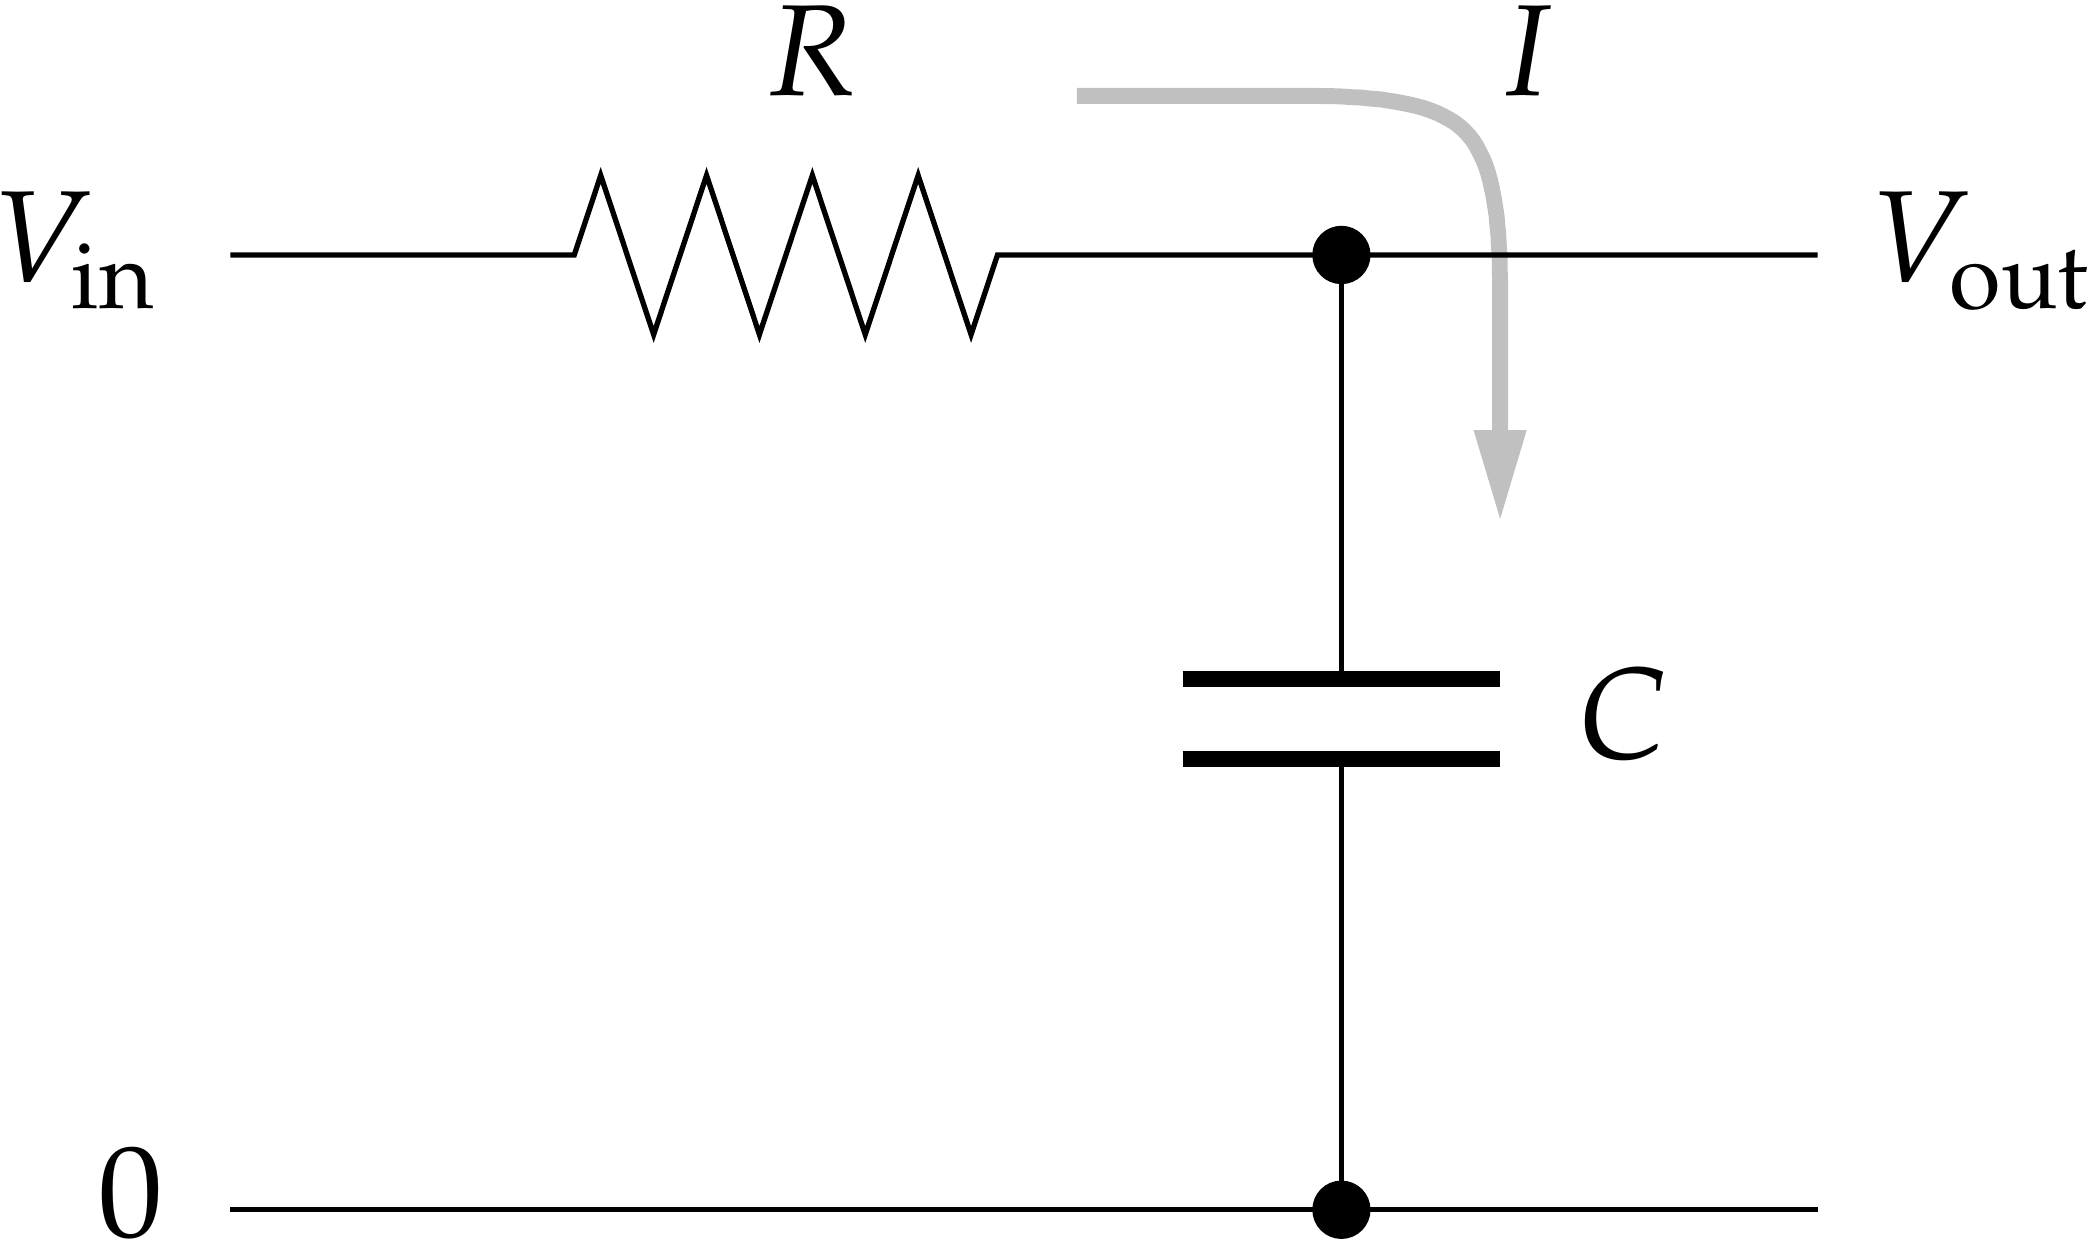

In [2]:
display(Image("low-pass.png",width=400))

- Las ecuaciones que gobiernan el comportamiento de este circuito son:
<br/>


   - La ley de Ohm:  $I\cdot R=\Delta V$,  siendo $R$ la resistencia.
   
   
   - La ley de los condensadores: $Q=C\cdot \Delta V$, siendo Q la carga eléctrica almacenada en la placa, $Q=\frac{\text{d}I}{\text{d}t}$ y $C$ la capacidad del condensador. 
   
   
1. Probar que al combinar  ambas ecuaciones podemos obtener que:

$$\frac{\text{d}V_{\text out}}{\text{d}t}=\frac{1}{RC}\left(V_\text{in}-V_\text{out}\right).$$

2. Obtener el valor de $V_\text{out}$ usando el método de Runge-Kutta de cuarto orden para el potencial de entrada corresponde a una señal cuadrada de frecuencia 1 y amplitud 1:

    $$V_\text{in}(t)=\left\{
    \begin{array}{cl}
    1& \text{if}\;\lfloor2t\rfloor\;\text{es par}\nonumber\\
    -1& \text{if}\;\lfloor2t\rfloor\;\text{es impar}\nonumber\\
    \end{array}\right.$$

    Usar el programa para representar el potencial de la señal de salida en el intervalo $t\in[0,10]$ s para un    circuito donde $RC=0.1$ con la condición inicial  $V_\text{0}=0$. Probar con varios pasos hasta elegir el valor de $h$ que te permite optimizar el cociente precisión/tiempo. 
   
   
3. Dado el resultado, explicar que es lo que esta haciendo el circuito.

---

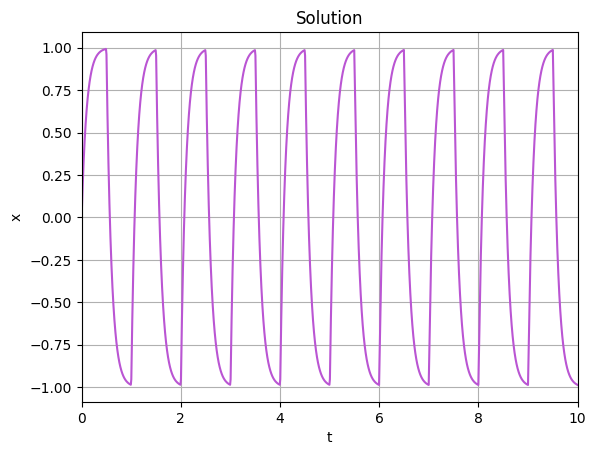

In [4]:
def rhs(x, t):
    return -x**3 + np.sin(t)


def runge_kutta_4(rhs, a, b, n, x0, display=False):
    h = (b - a) / n
    tp = np.linspace(a, b, n)
    xp = []
    x = x0

    for t in tp:
        xp.append(x)
        k1 = h * rhs(x, t)
        k2 = h * rhs(x + k1 / 2, t + h / 2)
        k3 = h * rhs(x + k2 / 2, t + h / 2)
        k4 = h * rhs(x + k3, t + h)
        x += (k1 + 2 * k2 + 2 * k3 + k4) / 6

    t = np.array(tp, float)
    x = np.array(xp, float)

    if display:
        plt.plot(t, x, color = mc)
        plt.title("Solution")
        plt.xlabel("t")
        plt.ylabel("x")
        plt.xlim(a, b)
        plt.grid()
        plt.show()

    return t, x


import numpy as np

def f(x, t):
    def vin(t):
        if int(2 * t) % 2 == 0:
            return 1
        else:
            return -1

    rc = 0.1
    return (vin(t) - x) / rc


t, x = runge_kutta_4(f, 0, 10, 1000, 0, 1)